In [1]:
import torch
print("Version:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU 0:", torch.cuda.get_device_name(0))
    print("GPU 0:", torch.cuda.get_device_name(1))


/home/s2154060/RDS/python/miniconda3/envs/dclvrt/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Version: 2.9.1+cu128
CUDA runtime: 12.8
CUDA available: True
GPU count: 2
GPU 0: NVIDIA GeForce RTX 3090
GPU 0: NVIDIA GeForce RTX 3090


# check datasets

In [2]:
import pandas as pd

In [3]:
import os
# https://huggingface.co/datasets/Qinghao/AcmeTrace
files_list = os.listdir('./AcmeTrace_job_trace')
print(files_list)

['philly_trace.csv', 'trace_kalos.csv', 'helios_trace.csv', 'philly_trace_merge_retry.csv', 'trace_seren.csv', 'pai_trace.csv', 'cluster_summary.csv']


In [4]:
for f in files_list:
    vars()['df_' + f.split('.')[0]] = pd.read_csv('AcmeTrace_job_trace/'+f)

In [5]:
df_cluster_summary

,id,job_num,cpu_job_num,gpu_job_num,avg_run_time_gpu,avg_que_time_gpu,avg_gpu_num,med_run_time_gpu,med_que_time_gpu,med_gpu_num,...,complete_rate_gpu_time,cancel_rate_gpu_time,fail_rate_gpu_time,avg_run_time_cpu,avg_que_time_cpu,med_run_time_cpu,med_que_time_cpu,complete_rate_cpu,cancel_rate_cpu,fail_rate_cpu
0,Seren,1031550,367737,663813,1414.335,445.984,5.680,122.000,1.0,1.0,...,0.212,0.664,0.124,733.894,4.813,14.0,1.0,0.858,0.039,0.102
1,Kalos,62413,42506,19907,1259.689,214.179,26.770,124.000,17.0,1.0,...,0.313,0.607,0.080,118.352,88.401,22.0,9.0,0.860,0.001,0.140
2,Philly,112956,0,112956,18006.055,3760.604,1.928,874.000,189.0,1.0,...,0.321,0.294,0.386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Helios,3362981,1782517,1580464,6651.681,862.047,3.716,206.000,0.0,1.0,...,0.513,0.394,0.093,628.759,73.907,2.0,0.0,0.909,0.030,0.061
4,PAI,1260920,0,1037085,4787.109,401.742,0.683,480.667,9.0,0.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## seren

In [6]:
df_trace_seren.apply(lambda col: col.unique())

job_id         [5778432, 5778469, 5778565, 5778592, 5778612, ...
user           [u5907, u8742, ud035, u685c, udc33, u9170, u5f...
node_num       [1, 2, 4, 32, 16, 8, 24, 36, 28, 3, 30, 29, 31...
gpu_num        [8, 16, 32, 0, 1, 256, 128, 64, 192, 144, 4, 2...
cpu_num        [128, 160, 320, 2, 32, 112, 16, 8, 256, 50, 10...
type              [Other, CPU, Debug, Pretrain, Eval, SFT, MLLM]
state          [FAILED, COMPLETED, CANCELLED, NODE_FAIL, TIME...
submit_time    [2023-03-01 00:18:22+08:00, 2023-03-01 00:23:5...
start_time     [2023-03-01 00:18:54+08:00, 2023-03-01 00:24:1...
end_time       [2023-03-01 00:20:51+08:00, 2023-03-01 01:09:0...
duration       [117, 2693, 35019, 46, 57202, 60604, 219, 115,...
queue          [32, 13, 2, 16, 5113, 1, 0, 3, 4, 29, 7, 10, 2...
gpu_time       [936.0, 21544.0, 280152.0, 736.0, 1830464.0, 1...
dtype: object

In [7]:
df_trace_seren

,job_id,user,node_num,gpu_num,cpu_num,type,state,submit_time,start_time,end_time,duration,queue,gpu_time
0,5778432,u5907,1,8,128,Other,FAILED,2023-03-01 00:18:22+08:00,2023-03-01 00:18:54+08:00,2023-03-01 00:20:51+08:00,117,32,936.0
1,5778469,u5907,1,8,128,Other,COMPLETED,2023-03-01 00:23:58+08:00,2023-03-01 00:24:11+08:00,2023-03-01 01:09:04+08:00,2693,13,21544.0
2,5778565,u8742,1,8,128,Other,FAILED,2023-03-01 00:43:51+08:00,2023-03-01 00:43:53+08:00,2023-03-01 10:27:32+08:00,35019,2,280152.0
3,5778592,ud035,2,16,160,Other,FAILED,2023-03-01 00:48:06+08:00,2023-03-01 00:48:08+08:00,2023-03-01 00:48:54+08:00,46,2,736.0
4,5778612,ud035,4,32,320,Other,COMPLETED,2023-03-01 00:52:01+08:00,2023-03-01 00:52:17+08:00,2023-03-01 16:45:39+08:00,57202,16,1830464.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
818322,7992042,ubd92,1,1,2,Eval,COMPLETED,2023-08-16 23:59:34+08:00,2023-08-16 23:59:36+08:00,2023-08-17 00:23:15+08:00,1419,2,1419.0
818323,7992043,ubd92,1,1,2,Eval,COMPLETED,2023-08-16 23:59:37+08:00,2023-08-16 23:59:39+08:00,2023-08-17 01:08:26+08:00,4127,2,4127.0
818324,7992044,ubd92,1,1,2,Eval,COMPLETED,2023-08-16 23:59:40+08:00,2023-08-16 23:59:42+08:00,2023-08-17 01:55:07+08:00,6925,2,6925.0
818325,7992045,ubd92,1,1,2,Eval,COMPLETED,2023-08-16 23:59:40+08:00,2023-08-16 23:59:42+08:00,2023-08-17 00:21:47+08:00,1325,2,1325.0


In [8]:
df_trace_seren.submit_time = pd.to_datetime(df_trace_seren.submit_time)

In [9]:
df_trace_seren = df_trace_seren[~df_trace_seren.type.isin(['Other', 'Debug','CPU'])]
df_trace_seren = df_trace_seren[df_trace_seren.state.isin(['COMPLETED'])]

In [10]:
df_trace_seren.type.value_counts()

type
Eval        134315
SFT          39349
MLLM          4667
Pretrain       971
Name: count, dtype: int64

In [11]:
df_trace_seren.groupby(by='type').describe().T.astype('int')

type                Eval      MLLM   Pretrain       SFT
job_id   count    134315      4667        971     39349
         mean    6985529   6408711    6501026   6186079
         std      481800    535281     661950    304513
         min     5863876   6046811    5786491   5936619
         25%     6611710   6090184    5941601   5999662
         50%     6922410   6195153    6288010   6160498
         75%     7356347   6314282    6948030   6237867
         max     7992046   7990394    7929283   7990480
node_num count    134315      4667        971     39349
         mean          1         1         27         1
         std           0         1         31         0
         min           1         1          5         1
         25%           1         1          8         1
         50%           1         1         16         1
         75%           1         1         32         1
         max          16        32        128        64
gpu_num  count    134315      4667        971     39349
         mean          2         5        222         6
         std           2        14        252         6
         min           1         1         40         1
         25%           1         1         64         2
         50%           1         2        128         8
         75%           2         8        256         8
         max         128       256       1024       512
cpu_num  count    134315      4667        971     39349
         mean          2        22       1496         5
         std           9       111       2036        49
         min           2         2         10         2
         25%           2         2        192         2
         50%           2         2        512         2
         75%           2         8       2048         2
         max        1024      2048       8192      4096
duration count    134315      4667        971     39349
         mean       1265      6155       5314       979
         std        9498     19883      27424      5953
         min           0         0          0         0
         25%         163       214         14       174
         50%         322       655         64       308
         75%         759      2495        319       599
         max     1166803    327617     527916    423131
queue    count    134315      4667        971     39349
         mean        249       718         67       173
         std        1363      3255        704      1418
         min           0         0          0         0
         25%           1         0          0         0
         50%           2         1          1         1
         75%          93         3          1         3
         max       68515     55609      15662     57277
gpu_time count    134315      4667        971     39349
         mean       4806    160432    1769872     19111
         std       76261   1688812   11701111    478903
         min           0         0          0         0
         25%         183       374       1456       499
         50%         424      2512       9792      2064
         75%        1648      9212      69920      3832
         max    12913248  40376448  193482752  37920000

## kalos

In [12]:
df_trace_kalos.apply(lambda col: col.unique())

job_id                [dlctk696s0jbvitv, dlcgiwd1g3i1cfgl, dlc1t2ypl...
user                  [uf794, u212a, u0260, ud094, u7b38, u98e1, u53...
node_num              [8, 4, 16, 1, 32, 2, 40, 37, 64, 128, 12, 127,...
gpu_num               [64, 32, 128, 8, 256, 16, 320, 0, 296, 2, 1, 5...
cpu_num               [960, 480, 1920, 120, 3840, 240, 4800, 4, 8, 3...
mem_per_pod_GB        [1000, 1600, 2, 32, 256, 64, 1, 100, 4, 1900, ...
shared_mem_per_pod    [100.0, 20.0, 0.0, 10.0, nan, 1.0, 1000.0, 4.0...
type                           [Other, Pretrain, Debug, CPU, SFT, Eval]
state                           [FAILED, CANCELLED, COMPLETED, RUNNING]
submit_time           [2023-05-17 11:00:58+00:00, 2023-05-17 11:21:3...
start_time            [2023-05-17 11:01:08+00:00, 2023-05-17 11:21:4...
end_time              [2023-05-17 11:01:16+00:00, 2023-05-17 11:21:5...
fail_time             [2023-05-17 11:01:16+00:00, 2023-05-17 11:21:5...
stop_time             [nan, 2023-05-17 11:30:04+00:00, 2023-05-1

In [13]:
df_trace_kalos

,job_id,user,node_num,gpu_num,cpu_num,mem_per_pod_GB,shared_mem_per_pod,type,state,submit_time,start_time,end_time,fail_time,stop_time,duration,queue,gpu_time
0,dlctk696s0jbvitv,uf794,8,64,960,1000,100.0,Other,FAILED,2023-05-17 11:00:58+00:00,2023-05-17 11:01:08+00:00,2023-05-17 11:01:16+00:00,2023-05-17 11:01:16+00:00,NaN,18,10.0,1152.0
1,dlcgiwd1g3i1cfgl,uf794,8,64,960,1000,100.0,Other,FAILED,2023-05-17 11:21:32+00:00,2023-05-17 11:21:45+00:00,2023-05-17 11:21:51+00:00,2023-05-17 11:21:51+00:00,NaN,19,13.0,1216.0
2,dlc1t2ypl09b8qtp,uf794,8,64,960,1000,100.0,Other,CANCELLED,2023-05-17 11:28:42+00:00,2023-05-17 11:28:54+00:00,2023-05-17 11:30:04+00:00,NaN,2023-05-17 11:30:04+00:00,82,12.0,5248.0
3,dlcj0vimc1r8uc4f,uf794,8,64,960,1000,100.0,Other,COMPLETED,2023-05-17 11:30:13+00:00,2023-05-17 11:30:25+00:00,2023-05-17 11:31:57+00:00,NaN,NaN,104,12.0,6656.0
4,dlcyu9s048ourmoe,uf794,8,64,960,1000,100.0,Other,COMPLETED,2023-05-17 11:35:26+00:00,2023-05-17 11:35:34+00:00,2023-05-17 11:36:44+00:00,NaN,NaN,78,8.0,4992.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62408,dlc2ep9txhmnjo8w,uc13a,1,8,48,256,NaN,Eval,COMPLETED,2023-08-16 14:09:13+00:00,2023-08-16 14:09:26+00:00,2023-08-16 14:41:00+00:00,NaN,NaN,1907,13.0,15256.0
62409,dlczzhretcl3wuyh,uc13a,1,8,48,256,NaN,Eval,COMPLETED,2023-08-16 14:28:19+00:00,2023-08-16 14:28:41+00:00,2023-08-16 14:59:16+00:00,NaN,NaN,1857,22.0,14856.0
62410,dlc10tkr9hhhppdi,uc13a,1,8,48,256,NaN,Eval,COMPLETED,2023-08-16 14:41:09+00:00,2023-08-16 14:41:26+00:00,2023-08-16 15:17:42+00:00,NaN,NaN,2193,17.0,17544.0
62411,dlc1nathj9nb8r8t,uc13a,1,8,48,256,NaN,Eval,RUNNING,2023-08-16 14:59:34+00:00,2023-08-16 15:00:04+00:00,NaN,NaN,NaN,1608,30.0,12864.0


In [14]:
df_trace_kalos = df_trace_kalos[~df_trace_kalos.type.isin(['Other', 'Debug','CPU'])]
df_trace_kalos = df_trace_kalos[df_trace_kalos.state.isin(['COMPLETED'])]

In [15]:
df_trace_kalos.type.value_counts()
# no MLLM

type
Eval        10304
Pretrain      183
SFT             6
Name: count, dtype: int64

In [16]:
df_trace_kalos.groupby(by='type').describe(percentiles=[]).T.astype('int')

type                        Eval   Pretrain      SFT
node_num           count   10304        183        6
                   mean        1         66        5
                   std         0         35        3
                   min         1         12        2
                   50%         1         64        5
                   max         1        128        8
gpu_num            count   10304        183        6
                   mean        1        532       40
                   std         1        283       26
                   min         1         96       16
                   50%         1        512       40
                   max         8       1024       64
cpu_num            count   10304        183        6
                   mean        9       7953      600
                   std         7       4274      394
                   min         6       1440      240
                   50%         8       7680      600
                   max        48      15360      960
mem_per_pod_GB     count   10304        183        6
                   mean       52       1377     1000
                   std        40        396        0
                   min        32       1000     1000
                   50%        48       1200     1000
                   max       256       1900     1000
shared_mem_per_pod count       3        183        6
                   mean        0        148      100
                   std         0        118        0
                   min         0         20      100
                   50%         0        100      100
                   max         0       1000      100
duration           count   10304        183        6
                   mean      744      20741    26666
                   std      1510      62605    59494
                   min        15         20       81
                   50%       234        351     3252
                   max     29536     625740   148082
queue              count   10304        183        6
                   mean      291         51       10
                   std       994        155        1
                   min         5          7        9
                   50%        30         13       10
                   max     27637       1083       13
gpu_time           count   10304        183        6
                   mean     1530    8637050  1627834
                   std      6975   28685351  3845610
                   min        25       5120     5184
                   50%       238     197064    52864
                   max    236288  315372960  9477248

## philly

In [17]:
df_philly_trace.apply(lambda col: col.unique())

jobname        [application_1506638472019_2050-attempt0, appl...
vc             [6.21E+12, 11cb48, b436b2, 6c71a0, e13805, ee9...
user           [ef4fdc, 6.60E+100, b22530, 592498, f2ae3f, b8...
state                                     [Killed, Pass, Failed]
submit_time    [2017/10/1 0:00, 2017/10/1 0:01, 2017/10/1 0:0...
start_time     [2017/10/1 0:00, 2017/10/1 0:01, 2017/10/1 0:0...
end_time       [2017/10/1 3:39, 2017/10/1 0:01, 2017/10/1 3:4...
gpu_num        [1, 2, 4, 8, 16, 32, 48, 64, 128, 24, 14, 7, 6...
gpu_alloc      [[1], [2], [4], [8], [8, 8], [8, 8, 8, 8], [8,...
node_list      [['m88'], ['m115'], ['m401'], ['m14'], ['m392'...
duration       [13138, 30, 13120, 13156, 13155, 13084, 13098,...
queue          [16, 11, 10, 8, 5, 14, 13, 138, 12, 7, 18, 20,...
dtype: object

In [18]:
# NOTE no job types
df_philly_trace

,jobname,vc,user,state,submit_time,start_time,end_time,gpu_num,gpu_alloc,node_list,duration,queue
0,application_1506638472019_2050-attempt0,6.21E+12,ef4fdc,Killed,2017/10/1 0:00,2017/10/1 0:00,2017/10/1 3:39,1,[1],['m88'],13138,16
1,application_1506638472019_2051-attempt0,6.21E+12,ef4fdc,Pass,2017/10/1 0:00,2017/10/1 0:00,2017/10/1 0:01,1,[1],['m115'],30,11
2,application_1506638472019_2052-attempt0,6.21E+12,ef4fdc,Killed,2017/10/1 0:00,2017/10/1 0:00,2017/10/1 3:39,1,[1],['m401'],13120,10
3,application_1506638472019_2053-attempt0,6.21E+12,ef4fdc,Killed,2017/10/1 0:00,2017/10/1 0:00,2017/10/1 3:40,1,[1],['m14'],13156,8
4,application_1506638472019_2054-attempt0,6.21E+12,ef4fdc,Killed,2017/10/1 0:01,2017/10/1 0:01,2017/10/1 3:40,1,[1],['m392'],13155,5
...,...,...,...,...,...,...,...,...,...,...,...,...
112951,application_1508364558011_47887-attempt3,103959,bf8cc2,Failed,2017/11/18 23:44,2017/11/18 23:47,2017/11/18 23:49,4,"[2, 2]","['m330', 'm325']",102,207
112952,application_1508364558011_47887-attempt4,103959,bf8cc2,Failed,2017/11/18 23:49,2017/11/18 23:52,2017/11/18 23:53,4,"[2, 2]","['m325', 'm330']",52,161
112953,application_1508364558011_47889-attempt0,11cb48,6.60E+100,Pass,2017/11/18 23:52,2017/11/18 23:52,2017/11/18 23:53,1,[1],['m189'],69,10
112954,application_1508364558011_47890-attempt0,103959,bf8cc2,Failed,2017/11/18 23:54,2017/11/18 23:56,2017/11/18 23:57,4,"[2, 2]","['m330', 'm325']",87,114


## helios

In [19]:
df_helios_trace.apply(lambda col: col.unique())

job_id         [363167, 394656, 394948, 396689, 396912, 39691...
cluster                           [Venus, Earth, Saturn, Uranus]
user           [u1Eem, uBFjQ, uhSlK, uLoqx, uINUJ, uhrp2, u7I...
vc             [vccJW, vcefl, vcHvQ, vcEwI, vcWoR, vchbv, vcL...
gpu_num        [32, 0, 8, 4, 24, 16, 2, 1, 48, 56, 5, 6, 12, ...
cpu_num        [160, 4, 1, 16, 24, 48, 8, 280, 32, 80, 20, 40...
node_num       [4, 1, 3, 2, 6, 7, 5, 10, 8, 12, 9, 11, 19, 16...
state          [TIMEOUT, FAILED, COMPLETED, CANCELLED, NODE_F...
submit_time    [2020-03-18 04:01:39, 2020-03-25 11:08:58, 202...
start_time     [2020-03-18 04:01:39, 2020-03-25 11:08:58, 202...
end_time       [2020-04-01 04:01:54, 2020-04-08 11:09:06, 202...
duration       [1209615, 1209608, 848439, 633257, 1209606, 12...
queue          [0, 1, 23069, 20, 16964, 48, 17464, 414692, 30...
dtype: object

In [20]:
# NOTE no job types
df_helios_trace

,job_id,cluster,user,vc,gpu_num,cpu_num,node_num,state,submit_time,start_time,end_time,duration,queue
0,363167,Venus,u1Eem,vccJW,32,160,4,TIMEOUT,2020-03-18 04:01:39,2020-03-18 04:01:39,2020-04-01 04:01:54,1209615,0
1,394656,Venus,uBFjQ,vcefl,0,4,1,TIMEOUT,2020-03-25 11:08:58,2020-03-25 11:08:58,2020-04-08 11:09:06,1209608,0
2,394948,Venus,uhSlK,vcHvQ,8,1,1,FAILED,2020-03-25 17:00:06,2020-03-25 17:00:06,2020-04-04 12:40:45,848439,0
3,396689,Venus,uLoqx,vcEwI,4,16,1,COMPLETED,2020-03-26 13:42:30,2020-03-26 13:42:30,2020-04-02 21:36:47,633257,0
4,396912,Venus,uINUJ,vcHvQ,8,16,1,TIMEOUT,2020-03-26 17:38:08,2020-03-26 17:38:08,2020-04-09 17:38:14,1209606,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3362976,1953483,Uranus,u1Xxf,vcUV3,24,24,3,CANCELLED,2020-09-27 23:55:29,2020-09-27 23:55:29,2020-09-27 23:58:26,177,0
3362977,1953484,Uranus,uGf7v,vcW23,8,40,1,CANCELLED,2020-09-27 23:55:38,2020-09-27 23:55:38,2020-09-28 00:01:44,366,0
3362978,1953485,Uranus,uGf7v,vcW23,8,40,1,CANCELLED,2020-09-27 23:58:20,2020-09-27 23:58:20,2020-09-28 00:01:44,204,0
3362979,1953486,Uranus,u1Xxf,vcUV3,24,24,3,COMPLETED,2020-09-27 23:58:32,2020-09-27 23:58:32,2020-09-28 00:24:06,1534,0


## pai

In [21]:
df_pai_trace.apply(lambda col: col.unique())

task_name       [tensorflow, worker, ps, PyTorchWorker, xCompu...
inst_num        [1.0, 100.0, 10.0, 4.0, 5.0, 20.0, 80.0, 8.0, ...
status                     [Terminated, Failed, Running, Waiting]
start_time      [2693235.0, 3399583.0, 2152271.0, 2172980.0, 2...
end_time        [2695847.0, 3399732.0, 2158213.0, nan, 2173216...
plan_cpu        [600.0, 400.0, 1000.0, 300.0, 1800.0, 800.0, 2...
plan_mem        [29.296875, 9.765625, 19.53125, 10.0, 19.55078...
plan_gpu        [50.0, 100.0, 10.0, nan, 25.0, 20.0, 5.0, 200....
gpu_type                     [MISC, nan, V100, T4, P100, V100M32]
status_j                   [Terminated, Failed, Running, Waiting]
start_time_j    [2693235.0, 3399583.0, 2152271.0, 2172974.0, 2...
end_time_j      [2695847.0, 3399732.0, 2158213.0, 2173216.0, n...
runtime         [2612.0, 149.0, 5942.0, nan, 242.0, 351.0, 40....
status_i        [Terminated, Interrupted, Running, Failed, Wai...
start_time_i    [2693240.0, 3399681.0, 2152280.0, 2172995.0, n...
end_time_i

In [22]:
# NOTE no job types
df_pai_trace

,task_name,inst_num,status,start_time,end_time,plan_cpu,plan_mem,plan_gpu,gpu_type,status_j,start_time_j,end_time_j,runtime,status_i,start_time_i,end_time_i,duration,queue,start_date
0,tensorflow,1.0,Terminated,2693235.0,2695847.0,600.0,29.296875,50.0,MISC,Terminated,2693235.0,2695847.0,2612.0,Terminated,2693240.0,2695847.0,2607.0,5.0,1970-02-01 12:07:15+08:00
1,tensorflow,1.0,Terminated,3399583.0,3399732.0,600.0,29.296875,100.0,MISC,Terminated,3399583.0,3399732.0,149.0,Terminated,3399681.0,3399732.0,51.0,98.0,1970-02-09 16:19:43+08:00
2,tensorflow,1.0,Terminated,2152271.0,2158213.0,600.0,29.296875,50.0,MISC,Terminated,2152271.0,2158213.0,5942.0,Terminated,2152280.0,2158213.0,5933.0,9.0,1970-01-26 05:51:11+08:00
3,worker,100.0,Failed,2172980.0,NaN,600.0,9.765625,10.0,MISC,Failed,2172974.0,2173216.0,NaN,Interrupted,2172995.0,NaN,NaN,15.0,1970-01-26 11:36:20+08:00
4,ps,10.0,Running,2172974.0,2173216.0,600.0,19.531250,NaN,NaN,Failed,2172974.0,2173216.0,242.0,Running,NaN,NaN,NaN,NaN,1970-01-26 11:36:14+08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1260915,tensorflow,1.0,Terminated,4725236.0,4727490.0,100.0,29.296875,25.0,MISC,Terminated,4725236.0,4727490.0,2254.0,Terminated,4725241.0,4727490.0,2249.0,5.0,1970-02-25 00:33:56+08:00
1260916,tensorflow,1.0,Failed,4788805.0,NaN,600.0,29.296875,100.0,P100,Failed,4788805.0,NaN,NaN,Failed,4788815.0,NaN,NaN,10.0,1970-02-25 18:13:25+08:00
1260917,tensorflow,1.0,Failed,4800428.0,NaN,600.0,29.296875,100.0,P100,Failed,4800428.0,NaN,NaN,Failed,4800441.0,NaN,NaN,13.0,1970-02-25 21:27:08+08:00
1260918,tensorflow,1.0,Terminated,4732036.0,4739163.0,600.0,29.296875,10.0,MISC,Terminated,4732036.0,4739163.0,7127.0,Terminated,4733523.0,4739163.0,5640.0,1487.0,1970-02-25 02:27:16+08:00


In [23]:
df_trace_kalos

,job_id,user,node_num,gpu_num,cpu_num,mem_per_pod_GB,shared_mem_per_pod,type,state,submit_time,start_time,end_time,fail_time,stop_time,duration,queue,gpu_time
27,dlc729ngkzgal94e,ud094,16,128,1920,1000,100.0,Pretrain,COMPLETED,2023-05-18 03:42:17+00:00,2023-05-18 03:42:31+00:00,2023-05-18 03:43:25+00:00,NaN,NaN,68,14.0,8704.0
30,dlckyr9xg7j917kl,ud094,32,256,3840,1000,100.0,Pretrain,COMPLETED,2023-05-18 05:38:19+00:00,2023-05-18 05:38:32+00:00,2023-05-18 05:44:14+00:00,NaN,NaN,355,13.0,90880.0
31,dlc1f7omx09ga7i5,ud094,32,256,3840,1000,100.0,Pretrain,COMPLETED,2023-05-18 05:57:13+00:00,2023-05-18 05:57:23+00:00,2023-05-18 06:03:04+00:00,NaN,NaN,351,10.0,89856.0
37,dlc1p8ajgkpvngdh,ud094,40,320,4800,1000,100.0,Pretrain,COMPLETED,2023-05-18 07:48:45+00:00,2023-05-18 07:49:04+00:00,2023-05-18 07:54:25+00:00,NaN,NaN,340,19.0,108800.0
51,dlc1y6i96sovk3v0,ud094,37,296,4440,1000,100.0,Pretrain,COMPLETED,2023-05-18 12:30:53+00:00,2023-05-18 12:31:17+00:00,2023-05-18 12:36:38+00:00,NaN,NaN,345,24.0,102120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62406,dlc1ailh51xd4zh8,uc13a,1,8,48,256,NaN,Eval,COMPLETED,2023-08-16 13:37:44+00:00,2023-08-16 13:37:58+00:00,2023-08-16 14:09:04+00:00,NaN,NaN,1880,14.0,15040.0
62407,dlc1txyo79m50qri,uc13a,1,8,48,256,NaN,Eval,COMPLETED,2023-08-16 13:55:59+00:00,2023-08-16 13:57:00+00:00,2023-08-16 14:28:10+00:00,NaN,NaN,1931,61.0,15448.0
62408,dlc2ep9txhmnjo8w,uc13a,1,8,48,256,NaN,Eval,COMPLETED,2023-08-16 14:09:13+00:00,2023-08-16 14:09:26+00:00,2023-08-16 14:41:00+00:00,NaN,NaN,1907,13.0,15256.0
62409,dlczzhretcl3wuyh,uc13a,1,8,48,256,NaN,Eval,COMPLETED,2023-08-16 14:28:19+00:00,2023-08-16 14:28:41+00:00,2023-08-16 14:59:16+00:00,NaN,NaN,1857,22.0,14856.0


In [24]:
df_trace_kalos = df_trace_kalos[~df_trace_kalos.type.isin(['Other', 'Debug','CPU'])]
df_trace_kalos = df_trace_kalos[df_trace_kalos.state.isin(['COMPLETED'])]

In [25]:
df_trace_kalos.type.value_counts()
# no MLLM

type
Eval        10304
Pretrain      183
SFT             6
Name: count, dtype: int64

In [26]:
df_trace_kalos.groupby(by='type').describe(percentiles=[]).T.astype('int')

type                        Eval   Pretrain      SFT
node_num           count   10304        183        6
                   mean        1         66        5
                   std         0         35        3
                   min         1         12        2
                   50%         1         64        5
                   max         1        128        8
gpu_num            count   10304        183        6
                   mean        1        532       40
                   std         1        283       26
                   min         1         96       16
                   50%         1        512       40
                   max         8       1024       64
cpu_num            count   10304        183        6
                   mean        9       7953      600
                   std         7       4274      394
                   min         6       1440      240
                   50%         8       7680      600
                   max        48      15360      960
mem_per_pod_GB     count   10304        183        6
                   mean       52       1377     1000
                   std        40        396        0
                   min        32       1000     1000
                   50%        48       1200     1000
                   max       256       1900     1000
shared_mem_per_pod count       3        183        6
                   mean        0        148      100
                   std         0        118        0
                   min         0         20      100
                   50%         0        100      100
                   max         0       1000      100
duration           count   10304        183        6
                   mean      744      20741    26666
                   std      1510      62605    59494
                   min        15         20       81
                   50%       234        351     3252
                   max     29536     625740   148082
queue              count   10304        183        6
                   mean      291         51       10
                   std       994        155        1
                   min         5          7        9
                   50%        30         13       10
                   max     27637       1083       13
gpu_time           count   10304        183        6
                   mean     1530    8637050  1627834
                   std      6975   28685351  3845610
                   min        25       5120     5184
                   50%       238     197064    52864
                   max    236288  315372960  9477248

In [27]:
df_trace_seren.type.drop_duplicates()

377      Pretrain
3401         Eval
9293          SFT
97585        MLLM
Name: type, dtype: object

## summary

there are 5 datesets, **seren, kalos, philly, heilos and pai**, only **seren and kalos** includes the job types  
seren has **[Other, CPU, Debug, Pretrain, Eval, SFT, MLLM]**, we can use **Pretrain, Eval, SFT, MLLM**  
kalos does not have MLLM (and only 6 SFT)  
the others no job types, (pai has GPU type which may can use for other study)


In [28]:
df_dataset_raw = pd.read_csv('AcmeTrace_job_trace/trace_seren.csv')

In [29]:
df_dataset_raw.submit_time = pd.to_datetime(df_dataset_raw.submit_time)
df_dataset_raw.start_time = pd.to_datetime(df_dataset_raw.start_time)
df_dataset_raw.end_time = pd.to_datetime(df_dataset_raw.end_time)


In [30]:
df_dataset = df_dataset_raw[~df_dataset_raw.type.isin(['Other', 'Debug','CPU'])]
df_dataset = df_dataset[df_dataset.state.isin(['COMPLETED'])]
df_dataset = df_dataset[df_dataset.duration>0]

## by type

In [31]:
df_dataset.type.value_counts()

type
Eval        134269
SFT          39326
MLLM          4656
Pretrain       948
Name: count, dtype: int64

In [32]:
df_dataset['slack'] = df_dataset.queue/df_dataset.duration

In [33]:
df_dataset[['gpu_num', 'duration', 'queue', 'type', 'slack']].groupby(by='type').describe(percentiles=[.05, .95]).T.round(3)

type                   Eval        MLLM    Pretrain         SFT
gpu_num  count   134269.000    4656.000     948.000   39326.000
         mean         2.339       5.740     220.751       6.090
         std          2.708      14.166     249.466       6.518
         min          1.000       1.000      40.000       1.000
         5%           1.000       1.000      48.000       1.000
         50%          1.000       2.000     128.000       8.000
         95%          8.000       8.000     768.000       8.000
         max        128.000     256.000    1024.000     512.000
duration count   134269.000    4656.000     948.000   39326.000
         mean      1266.184    6170.382    5443.522     980.082
         std       9499.776   19904.317   27742.750    5954.881
         min          1.000       1.000       1.000       1.000
         5%          93.000      31.000       1.000      78.000
         50%        322.000     658.000      73.500     308.000
         95%       3659.000   25125.250   31237.450    2726.000
         max    1166803.000  327617.000  527916.000  423131.000
queue    count   134269.000    4656.000     948.000   39326.000
         mean       250.044     720.618      68.909     173.314
         std       1364.003    3259.369     713.299    1418.961
         min          0.000       0.000       0.000       0.000
         5%           0.000       0.000       0.000       0.000
         50%          2.000       1.000       1.000       1.000
         95%        941.000    2221.000      34.000     523.000
         max      68515.000   55609.000   15662.000   57277.000
slack    count   134269.000    4656.000     948.000   39326.000
         mean         0.582       0.181       4.088       0.331
         std          2.554       1.004      96.423       2.368
         min          0.000       0.000       0.000       0.000
         5%           0.000       0.000       0.000       0.000
         50%          0.006       0.001       0.002       0.004
         95%          2.875       1.000       1.000       1.067
         max        230.518      33.069    2939.000     187.336

gpu_num: Pretrain ≫ SFT ≈ Eval ≈ MLLM  
duration: MLLM ≳ Pretrain ≫ Eval ≈ SFT  
queue: MLLM ≫ Eval ≈ SFT > Pretrain  
slack: Pretrain ≫ Eval > SFT > MLLM

## by day

In [34]:
df_dataset[['gpu_num', 'duration']].groupby(df_dataset.submit_time.dt.day_of_year).describe().T

submit_time       61          62          64          69          70     71   \
gpu_num  count    2.0    4.000000   13.000000    4.000000   53.000000    1.0   
         mean   128.0  228.000000  246.769231   60.000000  208.452830  960.0   
         std      0.0   56.000000   11.705795    4.618802  237.045481    NaN   
         min    128.0  144.000000  224.000000   56.000000   48.000000  960.0   
         25%    128.0  228.000000  240.000000   56.000000  128.000000  960.0   
         50%    128.0  256.000000  256.000000   60.000000  128.000000  960.0   
         75%    128.0  256.000000  256.000000   64.000000  128.000000  960.0   
         max    128.0  256.000000  256.000000   64.000000  992.000000  960.0   
duration count    2.0    4.000000   13.000000    4.000000   53.000000    1.0   
         mean    56.0  172.750000   36.307692  164.500000   52.169811   33.0   
         std      0.0  289.894665    2.868932  120.980715   30.977495    NaN   
         min     56.0    1.000000   32.000000   65.000000    7.000000   33.0   
         25%     56.0   17.500000   34.000000   65.750000   32.000000   33.0   
         50%     56.0   42.000000   36.000000  140.500000   39.000000   33.0   
         75%     56.0  197.250000   37.000000  239.250000   73.000000   33.0   
         max     56.0  606.000000   43.000000  312.000000  141.000000   33.0   

submit_time            72    73          74          76   ...            219  \
gpu_num  count    2.000000   1.0    8.000000    2.000000  ...     546.000000   
         mean    64.000000  64.0   64.000000   64.000000  ...       4.426740   
         std      0.000000   NaN    0.000000    0.000000  ...       8.482207   
         min     64.000000  64.0   64.000000   64.000000  ...       1.000000   
         25%     64.000000  64.0   64.000000   64.000000  ...       1.000000   
         50%     64.000000  64.0   64.000000   64.000000  ...       4.000000   
         75%     64.000000  64.0   64.000000   64.000000  ...       8.000000   
         max     64.000000  64.0   64.000000   64.000000  ...     128.000000   
duration count    2.000000   1.0    8.000000    2.000000  ...     546.000000   
         mean   158.000000   1.0   41.500000  254.000000  ...    4734.805861   
         std    222.031529   NaN  106.086218  346.482323  ...   23734.085482   
         min      1.000000   1.0    3.000000    9.000000  ...       1.000000   
         25%     79.500000   1.0    3.000000  131.500000  ...     124.000000   
         50%    158.000000   1.0    3.000000  254.000000  ...     986.000000   
         75%    236.500000   1.0    5.250000  376.500000  ...    3195.750000   
         max    315.000000   1.0  304.000000  499.000000  ...  268556.000000   

submit_time              220            221            222            223  \
gpu_num  count    209.000000    1811.000000    1197.000000    1653.000000   
         mean       3.066986       3.523468       2.925647       2.016334   
         std       11.737731      25.672305      27.258032      13.904608   
         min        1.000000       1.000000       1.000000       1.000000   
         25%        1.000000       1.000000       1.000000       1.000000   
         50%        1.000000       1.000000       1.000000       1.000000   
         75%        1.000000       2.000000       1.000000       1.000000   
         max      128.000000     512.000000     768.000000     512.000000   
duration count    209.000000    1811.000000    1197.000000    1653.000000   
         mean     749.803828     934.840972    1156.283208    1246.866909   
         std     4767.345904    6143.657622   10283.197008   10265.289437   
         min        5.000000       8.000000       1.000000       7.000000   
         25%      188.000000     221.500000      75.000000     138.000000   
         50%      214.000000     351.000000     137.000000     325.000000   
         75%      314.000000     722.000000     335.000000     633.000000   
         max    64135.000000  247458.000000  1

In [35]:
df_dataset[['gpu_num', 'duration']].groupby(df_dataset.submit_time.dt.day_of_year).describe(percentiles=[]).describe(percentiles=[]).T

count           mean            std       min           50%  \
gpu_num  count  161.0    1113.037267    1634.127802  1.000000    571.000000   
         mean   161.0      40.739712     118.149100  1.055351      7.348774   
         std    153.0      34.621641      64.079271  0.000000     11.229026   
         min    161.0      23.111801     101.876947  1.000000      1.000000   
         50%    161.0      38.972050     132.246222  1.000000      8.000000   
         max    161.0     316.683230     313.716680  2.000000    192.000000   
duration count  161.0    1113.037267    1634.127802  1.000000    571.000000   
         mean   161.0    3561.604728    8988.764145  1.000000   1388.518100   
         std    153.0   10586.617300   15713.885805  0.000000   5913.202384   
         min    161.0     593.130435    6158.978399  1.000000      9.000000   
         50%    161.0    1403.661491    6865.988269  1.000000    343.000000   
         max    161.0  151365.515528  184622.958895  1.000000  83915.000000   

                         max  
gpu_num  count  8.046000e+03  
         mean   9.600000e+02  
         std    4.064546e+02  
         min    9.600000e+02  
         50%    9.600000e+02  
         max    1.024000e+03  
duration count  8.046000e+03  
         mean   7.750900e+04  
         std    1.171060e+05  
         min    7.750900e+04  
         50%    7.750900e+04  
         max    1.166803e+06

In [36]:
df_timeline = pd.DataFrame(index=pd.date_range(start=str(df_dataset.start_time.min().round('min')), end=str(df_dataset.end_time.max().round('min')), freq='min'), columns=['num_gpu']).fillna(0.)
# df_timeline_raw = pd.DataFrame(index=pd.date_range(start=str(df_dataset.start_time.min().round('min')), end=str(df_dataset_raw.end_time.max().round('min')), freq='min'), columns=['num_gpu']).fillna(0.)

/tmp/ipykernel_122516/2241516727.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_timeline = pd.DataFrame(index=pd.date_range(start=str(df_dataset.start_time.min().round('min')), end=str(df_dataset.end_time.max().round('min')), freq='min'), columns=['num_gpu']).fillna(0.)


In [37]:
def gpu_summary(row, df):    
    st = row.start_time
    et = row.end_time
    gpu_num = row.gpu_num
    df.num_gpu.loc[st:et] += gpu_num

In [38]:
df_dataset.apply(lambda r: gpu_summary(r, df_timeline), axis=1)
# df_dataset_raw.apply(lambda r: gpu_summary(r, df_timeline_raw), axis=1)

/tmp/ipykernel_122516/1299565647.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.num_gpu.loc[st:et] += gpu_num


377       None
378       None
631       None
642       None
668       None
          ... 
818322    None
818323    None
818324    None
818325    None
818326    None
Length: 179199, dtype: object

In [39]:
df_timeline.describe()

,num_gpu
count,248784.000000
mean,258.987965
std,300.734461
min,0.000000
25%,11.000000
50%,178.000000
75%,332.000000
max,1705.000000


<Axes: >

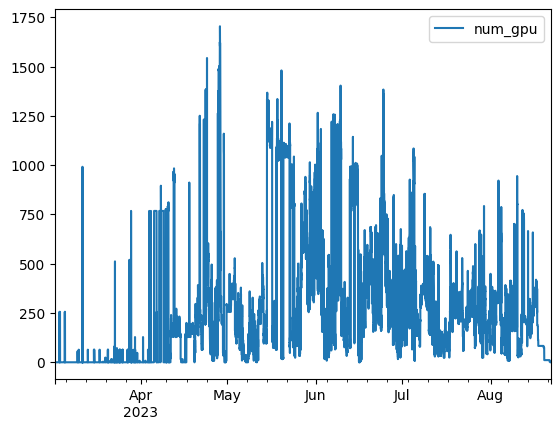

In [40]:
df_timeline.plot()